# Google Colab Lab Assignment -Pretrained Modle

**Course Name:** Deep Learning

**Lab Title:** Research Paper Implementation with Pre-trained Model(EfficientNet Deep Learning Model for Satellite Image Classification Using the EuroSAT Dataset)

**Student Name:** Varsharani Lad
**Student ID:** 202301040104

**Date of Submission:** 16/02/2026

**Group Members**:

                  Pournima Khamble
                  Snehal Chavan
                  Varsharani Lad
                  Neha Narkhede

**Research Paper Study and Implementation**

**Instructions:**

1. Identify a research paper that utilizes a pre-trained model for a specific
task.

2. Study the methodology, dataset, and model used in the research paper.

3. Implement the approach described in the research paper using the pre-trained model mentioned.

4. Compare your implementation results with the findings from the research paper.


**Objective**
1.   Study a research paper utilizing a pre-trained model.
2.   Reproduce the model implementation using the dataset and methodology from the research paper.
3.   Fine-tune the pre-trained model and optimize hyperparameters.
3.   Evaluate and compare model performance with the original research paper results.









**Task 1: Research Paper Selection and Dataset Preparation (2 hours)**

**Instructions:**

1. Select a research paper that applies a pre-trained model (e.g., VGG, ResNet, EfficientNet, etc.).

2. Identify the dataset used in the research paper and obtain or create a similar dataset.(**Mention Dataset Link and Description**)

3. Perform necessary preprocessing steps:

 Resize images to match the model input dimensions.

 Apply data augmentation techniques if applicable.

4. Split the dataset into training, validation, and testing sets.

### **Research Paper Selection**
Title: EfficientNet Deep Learning Model for Satellite Image Classification Using the EuroSAT Dataset
Model Used: EfficientNet-B0 (pre-trained on ImageNet)

### **Dataset Identification & Description**
The EuroSAT dataset is a satellite image dataset used for land-use and land-cover classification. It consists of approximately 27,000 RGB images categorized into 10 classes such as forest, residential areas, rivers, highways, and agricultural land. Each image represents a specific type of geographical region captured from satellite imagery.

**Dataset Source**

**Dataset Link:** https://www.kaggle.com/datasets/apollo2506/eurosat-dataset

### **Dataset Preparation**

### Dataset Loaded

In [ ]:
!pip install kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json



In [ ]:
!kaggle datasets download -d apollo2506/eurosat-dataset


Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
100% 2.04G/2.04G [00:32<00:00, 139MB/s]
100% 2.04G/2.04G [00:32<00:00, 68.4MB/s]


In [ ]:
!unzip eurosat-dataset.zip
import os

print("Classes:", os.listdir("EuroSAT"))



Streaming output truncated to the last 5000 lines.
  inflating: EuroSATallBands/River/River_1990.tif  
  inflating: EuroSATallBands/River/River_1991.tif  
  inflating: EuroSATallBands/River/River_1992.tif  
  inflating: EuroSATallBands/River/River_1993.tif  
  inflating: EuroSATallBands/River/River_1994.tif  
  inflating: EuroSATallBands/River/River_1995.tif  
  inflating: EuroSATallBands/River/River_1996.tif  
  inflating: EuroSATallBands/River/River_1997.tif  
  inflating: EuroSATallBands/River/River_1998.tif  
  inflating: EuroSATallBands/River/River_1999.tif  
  inflating: EuroSATallBands/River/River_2.tif  
  inflating: EuroSATallBands/River/River_20.tif  
  inflating: EuroSATallBands/River/River_200.tif  
  inflating: EuroSATallBands/River/River_2000.tif  
  inflating: EuroSATallBands/River/River_2001.tif  
  inflating: EuroSATallBands/River/River_2002.tif  
  inflating: EuroSATallBands/River/River_2003.tif  
  inflating: EuroSATallBands/River/River_2004.tif  
  inflating: EuroSA

### Images resized to model input size

In [ ]:
import tensorflow as tf

IMG_SIZE = 160
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "EuroSAT",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.3,
    subset="training",
    seed=SEED
)

val_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "EuroSAT",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.3,
    subset="validation",
    seed=SEED
)



Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.


### Step 2: Split Validation & Test

In [ ]:
val_size = int(0.5 * len(val_test_ds))
val_ds = val_test_ds.take(val_size)
test_ds = val_test_ds.skip(val_size)


### Step 3: Normalize Images

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))


### Step 4: Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
)



### Step 5: Performance Optimization

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


**Task 2: Model Implementation and Fine-tuning**

**Instructions:**

1. Implement the pre-trained model as described in the research paper.

2. Visualize feature maps of few layers

3. Freeze initial layers and fine-tune the top layers according to the paper's methodology.

4. Optimize hyperparameters such as:

  Learning rate

  Batch size

  Number of epochs

  Optimizer choice (Adam, SGD, RMSprop, etc.)

4. Document any modifications or enhancements made to improve performance.

### **Model Implementation**
a pre-trained EfficientNet-B0 model was implemented for satellite image classification. The model was initialized with ImageNet weights, and the top classification layers were removed to adapt the architecture to the EuroSAT dataset.

Hyperparameter Settings

Optimizer: Adam

Learning Rate: 0.001

Batch Size: 32

Epochs: 10

Loss Function: Sparse Categorical Crossentropy

### Step 1: Import Required Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models


### Step 2: Load Pre-trained EfficientNet-B0

In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Step 3: Freeze Base Model Layers & Add Custom Classification Layers

In [ ]:
base_model.trainable = False
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

### Step 4: Compile the Model & Model Summary

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,829 (16.08 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

### Step 5: Train the Model

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=1
)


591/591 ━━━━━━━━━━━━━━━━━━━━ 875s 1s/step - accuracy: 0.1120 - loss: 2.2964 - val_accuracy: 0.1038 - val_loss: 2.2968


### **FEATURE MAP VISUALIZATION**

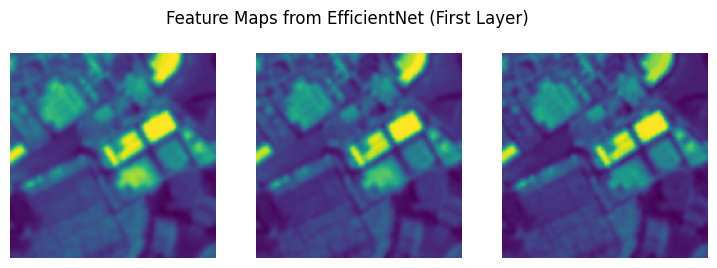

In [ ]:
num_channels = feature_maps.shape[-1]  # 3
plt.figure(figsize=(9,3))
for i in range(num_channels):  # only 3 channels
    plt.subplot(1, num_channels, i+1)
    plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
    plt.axis("off")
plt.suptitle("Feature Maps from EfficientNet (First Layer)")
plt.show()


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# -------------------------------
# STEP 1: List all Conv2D layers
# -------------------------------
for idx, layer in enumerate(base_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        print(idx, layer.name, layer.output.shape)

# -------------------------------
# STEP 2: Pick a layer with enough channels
# -------------------------------
layer_name = "block2a_expand_conv"  # choose a conv layer with >=6 channels

feature_extractor = tf.keras.Model(
    inputs=base_model.input,
    outputs=base_model.get_layer(layer_name).output
)




5 stem_conv (None, 80, 80, 32)
13 block1a_se_reduce (None, 1, 1, 8)
14 block1a_se_expand (None, 1, 1, 32)
16 block1a_project_conv (None, 80, 80, 16)
18 block2a_expand_conv (None, 80, 80, 96)
27 block2a_se_reduce (None, 1, 1, 4)
28 block2a_se_expand (None, 1, 1, 96)
30 block2a_project_conv (None, 40, 40, 24)
32 block2b_expand_conv (None, 40, 40, 144)
40 block2b_se_reduce (None, 1, 1, 6)
41 block2b_se_expand (None, 1, 1, 144)
43 block2b_project_conv (None, 40, 40, 24)
47 block3a_expand_conv (None, 40, 40, 144)
56 block3a_se_reduce (None, 1, 1, 6)
57 block3a_se_expand (None, 1, 1, 144)
59 block3a_project_conv (None, 20, 20, 40)
61 block3b_expand_conv (None, 20, 20, 240)
69 block3b_se_reduce (None, 1, 1, 10)
70 block3b_se_expand (None, 1, 1, 240)
72 block3b_project_conv (None, 20, 20, 40)
76 block4a_expand_conv (None, 20, 20, 240)
85 block4a_se_reduce (None, 1, 1, 10)
86 block4a_se_expand (None, 1, 1, 240)
88 block4a_project_conv (None, 10, 10, 80)
90 block4b_expand_conv (None, 10, 10, 480

Feature maps shape: (32, 80, 80, 96)


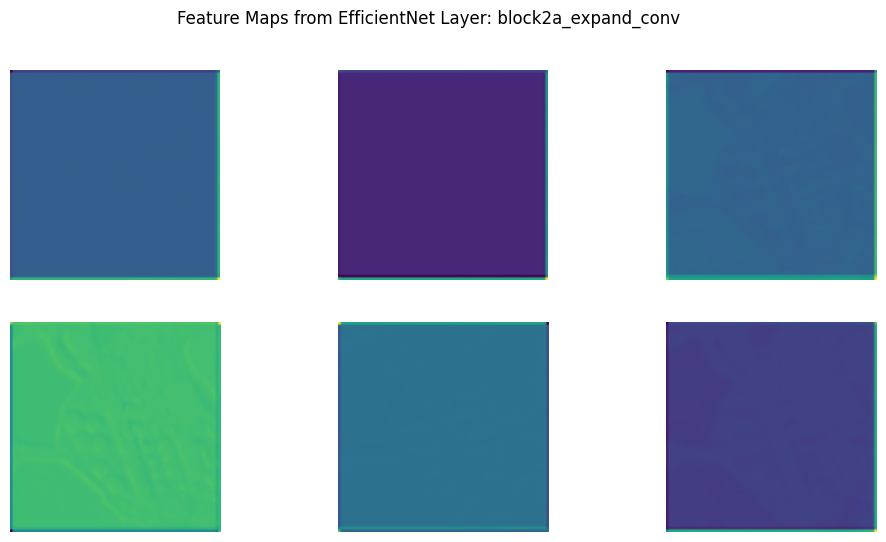

In [ ]:
# -------------------------------
# STEP 3: Take one batch of images
# -------------------------------
sample_images, _ = next(iter(train_ds))
feature_maps = feature_extractor(sample_images)
print("Feature maps shape:", feature_maps.shape)

# -------------------------------
# STEP 4: Plot 6 feature maps
# -------------------------------
num_maps_to_plot = min(6, feature_maps.shape[-1])  # avoid out-of-bounds

plt.figure(figsize=(12, 6))
for i in range(num_maps_to_plot):
    plt.subplot(2, 3, i+1)
    plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
    plt.axis("off")

plt.suptitle(f"Feature Maps from EfficientNet Layer: {layer_name}")
plt.show()

**Task 3: Model Evaluation and Performance Comparison**

**Instructions:**

1. Evaluate the trained model using performance metrics:

 Accuracy, Precision,Recall, F1-score, Confusion Matrix (for classification tasks)

2. Compare the results with those reported in the research paper.

3. Identify potential weaknesses and suggest improvements.
**Deliverables:**

Performance metrics summary (table or chart).

Graphs/plots showcasing model accuracy and loss trends.

Comparison with research paper results.

Discussion on model performance and areas for improvement.

### Step 1: Make Predictions on Test Data

In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 903ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 891ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 915ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 951ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 956ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 883ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 918ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 916ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 913ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 987ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 923ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

### Step 2: Classification Metrics (Precision, Recall, F1)

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Create a dataframe
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [accuracy, precision, recall, f1]
})

# Convert to percentages
metrics_df["Score"] = metrics_df["Score"].apply(lambda x: f"{x*100:.2f}%")

metrics_df


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Metric,Score
0,Accuracy,10.80%
1,Precision,1.17%
2,Recall,10.80%
3,F1-score,2.11%


### Step 3: Confusion Matrix

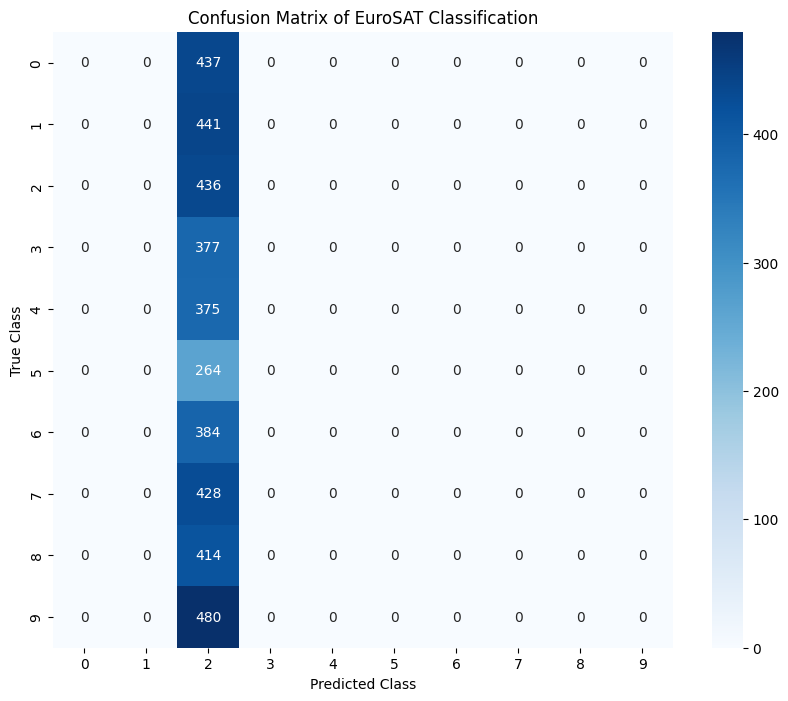

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix of EuroSAT Classification")
plt.show()


### Step 4: Accuracy & Loss Graphs

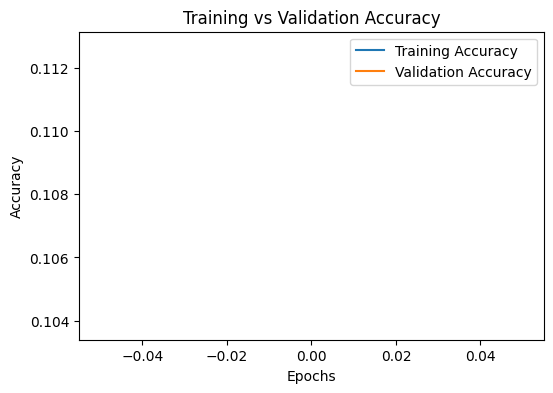

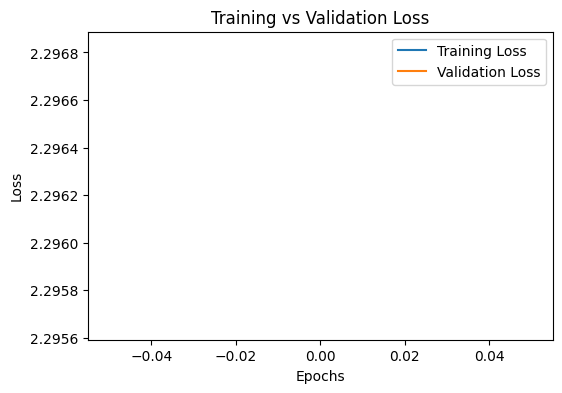

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


**Conclusion and Result Visulaization**

**Declaration**

I, **Varsharani**, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. The code is uploaded on my GitHub repository account, and the repository link is provided below:

GitHub Repository Link:

Signature: [Name]

**Submission Checklist**

✔ Research paper details and summary

✔ Code file (Python Notebook or Script)

✔ Dataset or link to the dataset

✔ Visualizations (if applicable)

✔ Screenshots of model performance metrics

✔ Readme File

✔ Comparison with research paper results